# 07 -- Volatility Prediction

**Predicts continuous realized forward volatility** using XGBoost regression on all 210 features.

Unlike the regime classifier (which bucketed vol into 2-4 classes), this predicts the actual number. The output converts directly to position sizing: `size = target_vol / predicted_vol`.

**Expanding window** with monthly retraining, same as notebook 06. Tests 20d, 40d, 60d forward windows.

**Evaluation:** R-squared, MAE, and a backtest where position sizing is inversely proportional to predicted vol.

In [1]:
import pandas as pd
import numpy as np
import os, sys
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.utils.class_weight import compute_sample_weight
import time
import warnings
warnings.filterwarnings('ignore')

PROJECT_DIR = os.path.dirname(os.path.abspath('__file__'))
PROCESSED_DIR = os.path.join(PROJECT_DIR, 'data', 'processed')
sys.path.insert(0, os.path.join(PROJECT_DIR, 'shared'))

merged = pd.read_csv(os.path.join(PROCESSED_DIR, 'merged_dataset.csv'),
                      parse_dates=['date'], index_col='date')
merged = merged[~merged.index.duplicated(keep='first')]

for col in ['fwd_vol', 'regime_label']:
    if col in merged.columns:
        merged = merged.drop(columns=[col])

print(f"Loaded: {len(merged)} rows, {merged.index[0].date()} to {merged.index[-1].date()}")

Loaded: 8047 rows, 1993-01-18 to 2024-12-31


In [2]:
exclude_cols = ['sprtrn', 'spindx']
feature_cols = [c for c in merged.columns if c not in exclude_cols]
X_all = merged[feature_cols].ffill().fillna(0)

X_np = X_all.values.astype(np.float32)
dates = X_all.index.values
spy_returns = merged['sprtrn'].values

print(f"Features: {X_np.shape}")

Features: (8047, 210)


20d forward vol: mean=0.157, median=0.133, std=0.099, valid=8027
40d forward vol: mean=0.159, median=0.133, std=0.094, valid=8007
60d forward vol: mean=0.161, median=0.134, std=0.091, valid=7987


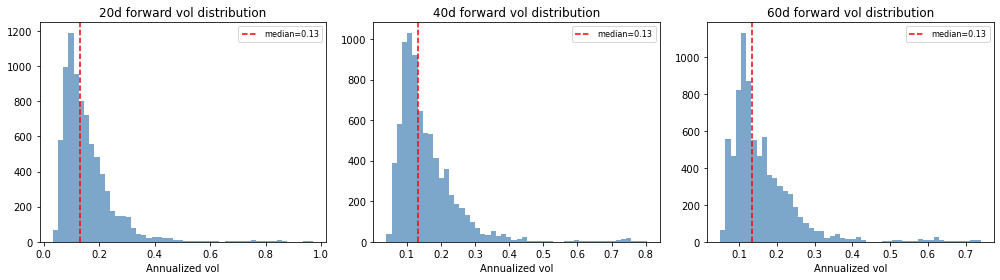

In [3]:
def compute_forward_vol(returns_np, window):
    """Realized annualized vol over the next `window` trading days."""
    n = len(returns_np)
    fwd_vol = np.full(n, np.nan)
    for i in range(n - window):
        fwd_vol[i] = np.std(returns_np[i:i+window], ddof=1) * np.sqrt(252)
    return fwd_vol

# Compute for all 3 windows
targets = {}
for w in [20, 40, 60]:
    fwd = compute_forward_vol(spy_returns, w)
    valid = ~np.isnan(fwd)
    targets[w] = fwd
    print(f"{w}d forward vol: mean={np.nanmean(fwd):.3f}, median={np.nanmedian(fwd):.3f}, "
          f"std={np.nanstd(fwd):.3f}, valid={valid.sum()}")

# Plot distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, w in enumerate([20, 40, 60]):
    fwd = targets[w]
    valid = fwd[~np.isnan(fwd)]
    axes[i].hist(valid, bins=50, color='steelblue', alpha=0.7)
    axes[i].axvline(x=np.median(valid), color='red', linestyle='--', label=f'median={np.median(valid):.2f}')
    axes[i].set_title(f'{w}d forward vol distribution')
    axes[i].set_xlabel('Annualized vol')
    axes[i].legend(fontsize=8)
plt.tight_layout()
plt.show()

In [4]:
def expanding_vol_predict(X_np, y_np, min_train_days=504,
                          retrain_every_days=21, embargo_days=60):
    """
    Expanding window regression. Monthly retraining.
    Returns predicted vol for every day after the warmup period.
    """
    n = len(X_np)
    valid_mask = ~np.isnan(y_np)
    
    pred_out = np.full(n, np.nan)
    models_trained = 0
    
    retrain_points = list(range(min_train_days, n, retrain_every_days))
    
    for retrain_idx in retrain_points:
        train_end = retrain_idx - embargo_days
        if train_end < 100:
            continue
        
        # Training: all valid data up to train_end
        train_valid = valid_mask[:train_end]
        tr_pos = np.where(train_valid)[0]
        
        if len(tr_pos) < 100:
            continue
        
        Xtr = X_np[tr_pos]
        ytr = y_np[tr_pos]
        
        # Test: next retrain_every_days days
        test_start = retrain_idx
        test_end = min(retrain_idx + retrain_every_days, n)
        te_pos = np.arange(test_start, test_end)
        
        if len(te_pos) == 0:
            continue
        
        Xte = X_np[te_pos]
        
        model = xgb.XGBRegressor(
            objective='reg:squarederror',
            n_estimators=200,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.6,
            min_child_weight=50,
            reg_alpha=1.0,
            reg_lambda=2.0,
            random_state=42,
            verbosity=0
        )
        model.fit(Xtr, ytr)
        
        pred = model.predict(Xte)
        # Clamp predictions to reasonable range
        pred = np.clip(pred, 0.03, 1.0)
        
        for j, pos in enumerate(te_pos):
            if np.isnan(pred_out[pos]):
                pred_out[pos] = pred[j]
        
        models_trained += 1
    
    return pred_out, models_trained

print("Expanding window regression engine ready.")

Expanding window regression engine ready.


In [5]:
# ============================================================
# Run expanding window for all 3 forward windows
# ============================================================

vol_results = {}

for w in [20, 40, 60]:
    print(f"\n{'='*60}")
    print(f"WINDOW: {w}d forward volatility")
    print(f"{'='*60}")
    
    y_np = targets[w]
    
    t0 = time.time()
    pred_vol, n_models = expanding_vol_predict(X_np, y_np)
    elapsed = time.time() - t0
    
    # Evaluate on days where we have both prediction and true value
    both_valid = (~np.isnan(pred_vol)) & (~np.isnan(y_np))
    n_eval = both_valid.sum()
    
    y_true = y_np[both_valid]
    y_pred = pred_vol[both_valid]
    
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    corr = np.corrcoef(y_true, y_pred)[0, 1]
    
    print(f"  Models trained: {n_models} | Time: {elapsed:.0f}s")
    print(f"  OOS predictions: {n_eval}")
    print(f"  R-squared:    {r2:.4f}")
    print(f"  Correlation:  {corr:.4f}")
    print(f"  MAE:          {mae:.4f}")
    print(f"  RMSE:         {rmse:.4f}")
    print(f"  Mean true:    {np.mean(y_true):.4f}")
    print(f"  Mean pred:    {np.mean(y_pred):.4f}")
    
    vol_results[w] = {
        'pred': pred_vol.copy(),
        'y_true': y_np.copy(),
        'r2': r2, 'mae': mae, 'rmse': rmse, 'corr': corr,
        'n_eval': n_eval, 'n_models': n_models,
    }


WINDOW: 20d forward volatility
  Models trained: 360 | Time: 527s
  OOS predictions: 7523
  R-squared:    0.2503
  Correlation:  0.5042
  MAE:          0.0537
  RMSE:         0.0875
  Mean true:    0.1610
  Mean pred:    0.1620

WINDOW: 40d forward volatility
  Models trained: 360 | Time: 527s
  OOS predictions: 7503
  R-squared:    0.1513
  Correlation:  0.4185
  MAE:          0.0550
  RMSE:         0.0878
  Mean true:    0.1641
  Mean pred:    0.1641

WINDOW: 60d forward volatility
  Models trained: 360 | Time: 502s
  OOS predictions: 7483
  R-squared:    -0.0556
  Correlation:  0.3023
  MAE:          0.0607
  RMSE:         0.0943
  Mean true:    0.1660
  Mean pred:    0.1692


In [6]:
print("=" * 70)
print("VOLATILITY PREDICTION -- EXPANDING WINDOW OOS RESULTS")
print("=" * 70)
print(f"{'Window':<10} {'R-squared':>10} {'Correlation':>12} {'MAE':>10} {'RMSE':>10} {'OOS Days':>10}")
print("-" * 65)

for w in [20, 40, 60]:
    r = vol_results[w]
    print(f"{w}d{'':<7} {r['r2']:>10.4f} {r['corr']:>12.4f} {r['mae']:>10.4f} {r['rmse']:>10.4f} {r['n_eval']:>10}")

VOLATILITY PREDICTION -- EXPANDING WINDOW OOS RESULTS
Window      R-squared  Correlation        MAE       RMSE   OOS Days
-----------------------------------------------------------------
20d            0.2503       0.5042     0.0537     0.0875       7523
40d            0.1513       0.4185     0.0550     0.0878       7503
60d           -0.0556       0.3023     0.0607     0.0943       7483


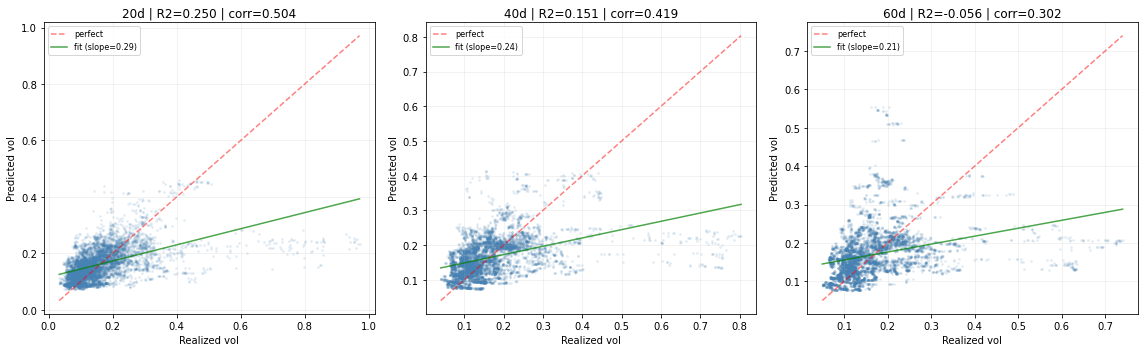

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, w in enumerate([20, 40, 60]):
    r = vol_results[w]
    pred = r['pred']
    true = r['y_true']
    both = (~np.isnan(pred)) & (~np.isnan(true))
    
    y_t = true[both]
    y_p = pred[both]
    
    axes[i].scatter(y_t, y_p, alpha=0.1, s=3, color='steelblue')
    
    # Perfect prediction line
    lims = [min(y_t.min(), y_p.min()), max(y_t.max(), y_p.max())]
    axes[i].plot(lims, lims, 'r--', alpha=0.5, label='perfect')
    
    # Best fit line
    z = np.polyfit(y_t, y_p, 1)
    axes[i].plot(lims, np.polyval(z, lims), 'g-', alpha=0.7, label=f'fit (slope={z[0]:.2f})')
    
    axes[i].set_xlabel('Realized vol')
    axes[i].set_ylabel('Predicted vol')
    axes[i].set_title(f'{w}d | R2={r["r2"]:.3f} | corr={r["corr"]:.3f}')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

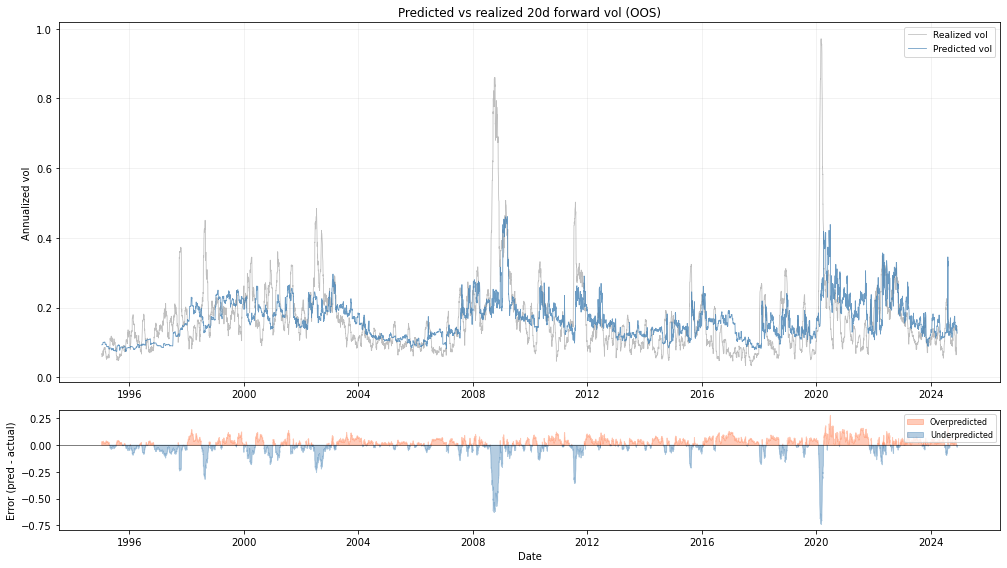

Best window by correlation: 20d (corr=0.5042)


In [8]:
# Plot predicted vs realized vol over time for best window
best_w = max(vol_results, key=lambda w: vol_results[w]['corr'])
r = vol_results[best_w]

both = (~np.isnan(r['pred'])) & (~np.isnan(r['y_true']))
plot_dates = dates[both]
plot_true = r['y_true'][both]
plot_pred = r['pred'][both]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

axes[0].plot(plot_dates, plot_true, label='Realized vol', alpha=0.5, linewidth=0.8, color='gray')
axes[0].plot(plot_dates, plot_pred, label='Predicted vol', alpha=0.8, linewidth=0.8, color='steelblue')
axes[0].set_title(f'Predicted vs realized {best_w}d forward vol (OOS)')
axes[0].set_ylabel('Annualized vol')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.2)

# Prediction error
error = plot_pred - plot_true
axes[1].fill_between(plot_dates, error, 0, alpha=0.4, color='coral',
                      where=error > 0, label='Overpredicted')
axes[1].fill_between(plot_dates, error, 0, alpha=0.4, color='steelblue',
                      where=error < 0, label='Underpredicted')
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].set_ylabel('Error (pred - actual)')
axes[1].set_xlabel('Date')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Best window by correlation: {best_w}d (corr={r['corr']:.4f})")

In [9]:
# ============================================================
# Vol-targeting backtest
# ============================================================
# Position size = target_vol / predicted_vol, clamped to [0.25, 1.5]
# If predicted vol is high -> reduce position
# If predicted vol is low -> increase position (up to 1.5x)

TARGET_VOL = 0.15  # 15% annualized target
MIN_EXPOSURE = 0.25
MAX_EXPOSURE = 1.50

print("=" * 75)
print("VOL-TARGETING BACKTEST (position size = target_vol / predicted_vol)")
print("=" * 75)
print(f"Target vol: {TARGET_VOL:.0%} | Exposure range: [{MIN_EXPOSURE:.0%}, {MAX_EXPOSURE:.0%}]")

def sharpe(r):
    return np.sqrt(252) * np.mean(r) / np.std(r) if np.std(r) > 0 else 0
def max_dd(c):
    peak = np.maximum.accumulate(c)
    return np.min((c - peak) / peak)
def cagr(c):
    yrs = len(c) / 252
    return c[-1] ** (1/yrs) - 1 if yrs > 0 else 0

print(f"\n{'Window':<8} {'SPY Sh':>8} {'VT Sh':>8} {'Impr':>8} {'SPY DD':>8} {'VT DD':>8} "
      f"{'DD Impr':>8} {'SPY CAGR':>9} {'VT CAGR':>9} {'Exposure':>9}")
print("-" * 95)

bt_vol_results = {}

for w in [20, 40, 60]:
    pred = vol_results[w]['pred']
    
    # Only days where we have predictions
    valid = ~np.isnan(pred)
    v_dates = dates[valid]
    v_spy = spy_returns[valid]
    v_pred = pred[valid]
    
    # Compute exposure: target_vol / predicted_vol, clamped
    exposure = np.clip(TARGET_VOL / v_pred, MIN_EXPOSURE, MAX_EXPOSURE)
    
    # Lag by 1 day
    exposure_lagged = np.roll(exposure, 1)
    exposure_lagged[0] = 1.0
    
    # Vol-targeted returns
    vt_returns = v_spy * exposure_lagged
    
    spy_cum = np.cumprod(1 + v_spy)
    vt_cum = np.cumprod(1 + vt_returns)
    
    spy_sh = sharpe(v_spy)
    vt_sh = sharpe(vt_returns)
    spy_dd = max_dd(spy_cum)
    vt_dd = max_dd(vt_cum)
    spy_cg = cagr(spy_cum)
    vt_cg = cagr(vt_cum)
    avg_exp = np.mean(exposure_lagged)
    
    print(f"{w}d{'':<5} {spy_sh:>8.3f} {vt_sh:>8.3f} {vt_sh-spy_sh:>+8.3f} "
          f"{spy_dd:>7.1%} {vt_dd:>7.1%} {vt_dd-spy_dd:>+7.1%} "
          f"{spy_cg:>8.1%} {vt_cg:>8.1%} {avg_exp:>8.1%}")
    
    bt_vol_results[w] = {
        'dates': v_dates, 'spy_cum': spy_cum, 'vt_cum': vt_cum,
        'spy_returns': v_spy, 'vt_returns': vt_returns,
        'exposure': exposure_lagged,
        'spy_sharpe': spy_sh, 'vt_sharpe': vt_sh,
        'spy_maxdd': spy_dd, 'vt_maxdd': vt_dd,
        'spy_cagr': spy_cg, 'vt_cagr': vt_cg,
        'avg_exposure': avg_exp,
    }

VOL-TARGETING BACKTEST (position size = target_vol / predicted_vol)
Target vol: 15% | Exposure range: [25%, 150%]

Window     SPY Sh    VT Sh     Impr   SPY DD    VT DD  DD Impr  SPY CAGR   VT CAGR  Exposure
-----------------------------------------------------------------------------------------------
20d         0.544    0.620   +0.077  -56.8%  -45.6%  +11.2%     8.8%     9.0%   101.3%
40d         0.544    0.633   +0.089  -56.8%  -44.2%  +12.6%     8.8%     9.4%    99.4%
60d         0.544    0.582   +0.038  -56.8%  -45.7%  +11.0%     8.8%     8.5%    97.6%


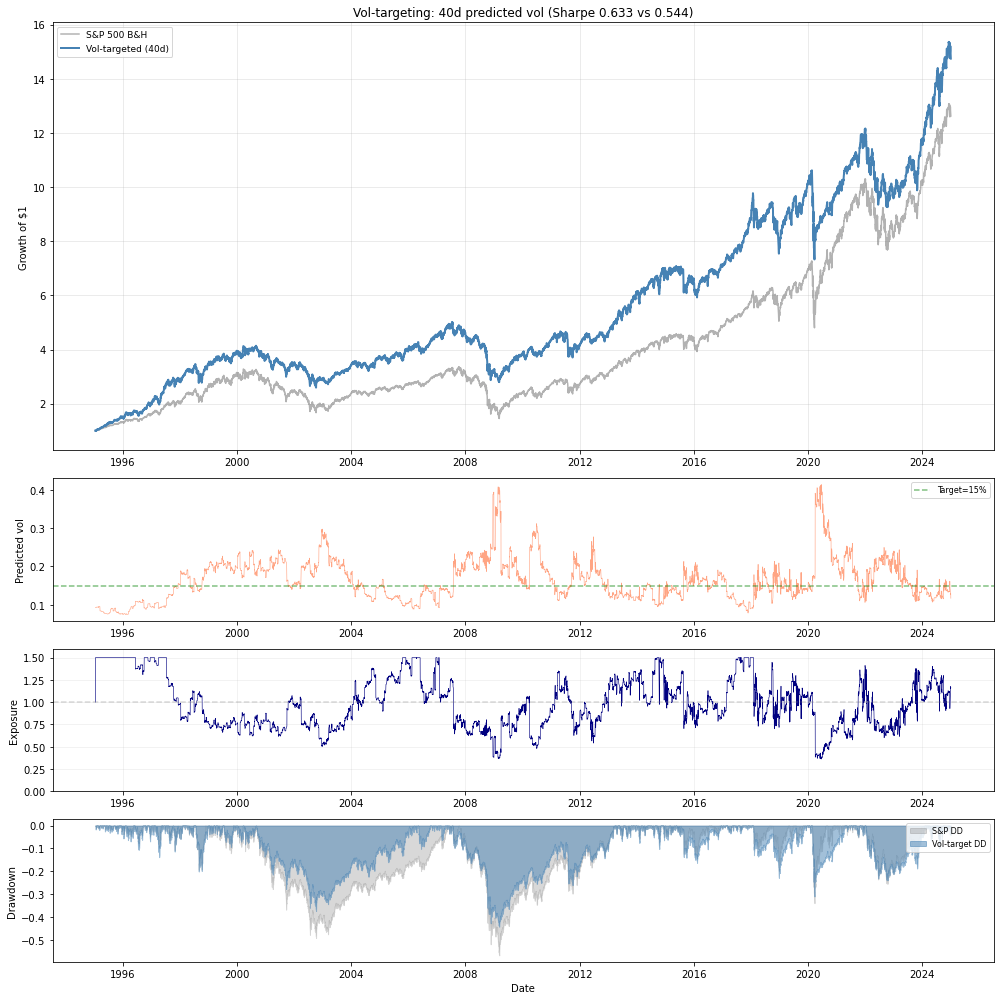

In [10]:
# Best by Sharpe improvement
best_w = max(bt_vol_results, key=lambda w: bt_vol_results[w]['vt_sharpe'] - bt_vol_results[w]['spy_sharpe'])
bt = bt_vol_results[best_w]

fig, axes = plt.subplots(4, 1, figsize=(14, 14),
                          gridspec_kw={'height_ratios': [3, 1, 1, 1]})

x = bt['dates']

axes[0].plot(x, bt['spy_cum'], label='S&P 500 B&H', alpha=0.6, color='gray')
axes[0].plot(x, bt['vt_cum'], label=f'Vol-targeted ({best_w}d)', linewidth=2, color='steelblue')
axes[0].set_title(f'Vol-targeting: {best_w}d predicted vol (Sharpe {bt["vt_sharpe"]:.3f} vs {bt["spy_sharpe"]:.3f})')
axes[0].legend(fontsize=9)
axes[0].set_ylabel('Growth of $1')
axes[0].grid(True, alpha=0.3)

# Predicted vol
pred = vol_results[best_w]['pred']
valid = ~np.isnan(pred)
axes[1].plot(dates[valid], pred[valid], color='coral', linewidth=0.6, alpha=0.7)
axes[1].axhline(y=TARGET_VOL, color='green', linestyle='--', alpha=0.5, label=f'Target={TARGET_VOL:.0%}')
axes[1].set_ylabel('Predicted vol')
axes[1].legend(fontsize=8)

# Exposure
axes[2].plot(x, bt['exposure'], color='navy', linewidth=0.6)
axes[2].axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
axes[2].set_ylabel('Exposure')
axes[2].set_ylim(0, MAX_EXPOSURE + 0.1)
axes[2].grid(True, alpha=0.2)

# Drawdown
spy_dd = (bt['spy_cum'] - np.maximum.accumulate(bt['spy_cum'])) / np.maximum.accumulate(bt['spy_cum'])
vt_dd = (bt['vt_cum'] - np.maximum.accumulate(bt['vt_cum'])) / np.maximum.accumulate(bt['vt_cum'])
axes[3].fill_between(x, spy_dd, 0, alpha=0.3, color='gray', label='S&P DD')
axes[3].fill_between(x, vt_dd, 0, alpha=0.5, color='steelblue', label='Vol-target DD')
axes[3].set_ylabel('Drawdown')
axes[3].legend(fontsize=8)
axes[3].set_xlabel('Date')

plt.tight_layout()
plt.show()

In [11]:
best_w = max(bt_vol_results, key=lambda w: bt_vol_results[w]['vt_sharpe'] - bt_vol_results[w]['spy_sharpe'])
bt = bt_vol_results[best_w]

crises = {
    'Dot-com (2000-02)': ('2000-03-01', '2002-10-01'),
    'GFC (2007-09)':     ('2007-10-01', '2009-03-01'),
    'Euro crisis (2011)':('2011-07-01', '2011-10-01'),
    'China/Oil (2015)':  ('2015-08-01', '2016-02-01'),
    'COVID (2020)':      ('2020-02-01', '2020-04-01'),
    'Rate hikes (2022)': ('2022-01-01', '2022-10-01'),
}

bt_dates_ts = pd.DatetimeIndex(bt['dates'])

print(f"Vol-targeting crisis analysis ({best_w}d)")
print(f"\n{'Crisis':<25} {'S&P':>10} {'Vol-tgt':>10} {'Exposure':>10} {'Helped?':>10}")
print("-" * 68)

for name, (start, end) in crises.items():
    mask = (bt_dates_ts >= start) & (bt_dates_ts <= end)
    if mask.sum() < 5:
        print(f"{name:<25} {'(not in OOS)':>42}")
        continue
    s = np.prod(1 + bt['spy_returns'][mask]) - 1
    f = np.prod(1 + bt['vt_returns'][mask]) - 1
    e = np.mean(bt['exposure'][mask])
    h = "YES" if f > s else "no"
    print(f"{name:<25} {s:>9.1%} {f:>9.1%} {e:>9.1%} {h:>10}")

Vol-targeting crisis analysis (40d)

Crisis                           S&P    Vol-tgt   Exposure    Helped?
--------------------------------------------------------------------
Dot-com (2000-02)            -37.9%    -26.2%     79.2%        YES
GFC (2007-09)                -51.9%    -39.9%     67.4%        YES
Euro crisis (2011)           -14.3%    -15.9%    107.1%         no
China/Oil (2015)              -7.8%    -11.0%     94.5%         no
COVID (2020)                 -23.4%    -20.5%     94.5%        YES
Rate hikes (2022)            -24.8%    -23.1%     80.5%        YES


In [12]:
# ============================================================
# Compare with regime filter (load from saved CSVs if available)
# ============================================================

print("=" * 80)
print("COMPARISON: Regime Filter vs Vol-Targeting vs Buy & Hold")
print("=" * 80)

# Try to load best regime filter
regime_path = os.path.join(PROCESSED_DIR, 'regime_signal.csv')
if os.path.exists(regime_path):
    regime_df = pd.read_csv(regime_path, parse_dates=[0], index_col=0)
    
    # Align regime signal with our dates
    regime_exposure = np.ones(len(dates))
    for i, dt in enumerate(dates):
        dt_ts = pd.Timestamp(dt)
        if dt_ts in regime_df.index:
            regime_exposure[i] = regime_df.loc[dt_ts, 'exposure']
    
    # Backtest regime filter
    best_vt = bt_vol_results[best_w]
    valid_vt = ~np.isnan(vol_results[best_w]['pred'])
    
    # Use same period as vol-targeting for fair comparison
    regime_exp_valid = regime_exposure[valid_vt]
    regime_exp_lagged = np.roll(regime_exp_valid, 1)
    regime_exp_lagged[0] = 1.0
    regime_returns = spy_returns[valid_vt] * regime_exp_lagged
    regime_cum = np.cumprod(1 + regime_returns)
    
    print(f"\nPeriod: {pd.Timestamp(dates[valid_vt][0]).date()} to {pd.Timestamp(dates[valid_vt][-1]).date()}")
    print(f"\n{'Strategy':<25} {'Sharpe':>10} {'MaxDD':>10} {'CAGR':>10} {'Exposure':>10}")
    print("-" * 68)
    print(f"{'S&P 500 B&H':<25} {best_vt['spy_sharpe']:>10.3f} {best_vt['spy_maxdd']:>9.1%} {best_vt['spy_cagr']:>9.1%} {'100%':>10}")
    print(f"{'Regime Filter (best)':<25} {sharpe(regime_returns):>10.3f} {max_dd(regime_cum):>9.1%} {cagr(regime_cum):>9.1%} {np.mean(regime_exp_lagged):>9.1%}")
    print(f"{'Vol-Targeting ({best_w}d)':<25} {best_vt['vt_sharpe']:>10.3f} {best_vt['vt_maxdd']:>9.1%} {best_vt['vt_cagr']:>9.1%} {best_vt['avg_exposure']:>9.1%}")
else:
    print("No regime_signal.csv found. Run notebook 06 first for comparison.")
    best_vt = bt_vol_results[best_w]
    print(f"\n{'Strategy':<25} {'Sharpe':>10} {'MaxDD':>10} {'CAGR':>10} {'Exposure':>10}")
    print("-" * 68)
    print(f"{'S&P 500 B&H':<25} {best_vt['spy_sharpe']:>10.3f} {best_vt['spy_maxdd']:>9.1%} {best_vt['spy_cagr']:>9.1%} {'100%':>10}")
    print(f"{'Vol-Targeting ({best_w}d)':<25} {best_vt['vt_sharpe']:>10.3f} {best_vt['vt_maxdd']:>9.1%} {best_vt['vt_cagr']:>9.1%} {best_vt['avg_exposure']:>9.1%}")

COMPARISON: Regime Filter vs Vol-Targeting vs Buy & Hold

Period: 1995-01-16 to 2024-12-31

Strategy                      Sharpe      MaxDD       CAGR   Exposure
--------------------------------------------------------------------
S&P 500 B&H                    0.544    -56.8%      8.8%       100%
Regime Filter (best)           0.584    -36.6%      7.5%     64.0%
Vol-Targeting ({best_w}d)      0.633    -44.2%      9.4%     99.4%


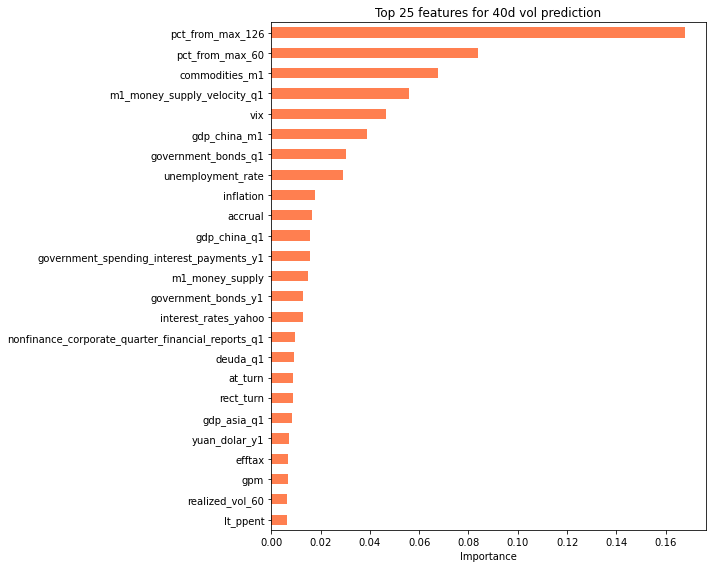


Top 15 features (40d vol):
  pct_from_max_126                              0.1678
  pct_from_max_60                               0.0837
  commodities_m1                                0.0677
  m1_money_supply_velocity_q1                   0.0559
  vix                                           0.0465
  gdp_china_m1                                  0.0389
  government_bonds_q1                           0.0302
  unemployment_rate                             0.0290
  inflation                                     0.0178
  accrual                                       0.0164
  gdp_china_q1                                  0.0159
  government_spending_interest_payments_y1      0.0158
  m1_money_supply                               0.0149
  government_bonds_y1                           0.0129
  interest_rates_yahoo                          0.0129


In [13]:
# Train on full data for feature importance
best_w = max(bt_vol_results, key=lambda w: bt_vol_results[w]['vt_sharpe'] - bt_vol_results[w]['spy_sharpe'])
y_fi = targets[best_w]
valid_fi = ~np.isnan(y_fi)

model_fi = xgb.XGBRegressor(
    objective='reg:squarederror', n_estimators=200, max_depth=5,
    learning_rate=0.05, subsample=0.8, colsample_bytree=0.6,
    min_child_weight=50, reg_alpha=1.0, reg_lambda=2.0,
    random_state=42, verbosity=0
)
model_fi.fit(X_np[valid_fi], y_fi[valid_fi])

importance = pd.Series(model_fi.feature_importances_, index=feature_cols)
top_25 = importance.nlargest(25)

fig, ax = plt.subplots(figsize=(10, 8))
top_25.sort_values().plot.barh(ax=ax, color='coral')
ax.set_title(f'Top 25 features for {best_w}d vol prediction')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print(f"\nTop 15 features ({best_w}d vol):")
for fname, imp in top_25.head(15).items():
    print(f"  {fname:<45} {imp:.4f}")

In [14]:
# Save vol predictions for all windows
for w in [20, 40, 60]:
    pred = vol_results[w]['pred']
    valid = ~np.isnan(pred)
    
    df_out = pd.DataFrame(index=pd.DatetimeIndex(dates[valid]))
    df_out['predicted_vol'] = pred[valid]
    df_out['exposure'] = np.clip(TARGET_VOL / pred[valid], MIN_EXPOSURE, MAX_EXPOSURE)
    
    fname = f'vol_prediction_{w}d.csv'
    df_out.to_csv(os.path.join(PROCESSED_DIR, fname))
    print(f"Saved {fname} ({valid.sum()} rows)")

# Save best as default
best_w = max(bt_vol_results, key=lambda w: bt_vol_results[w]['vt_sharpe'] - bt_vol_results[w]['spy_sharpe'])
pred = vol_results[best_w]['pred']
valid = ~np.isnan(pred)

df_best = pd.DataFrame(index=pd.DatetimeIndex(dates[valid]))
df_best['predicted_vol'] = pred[valid]
df_best['exposure'] = np.clip(TARGET_VOL / pred[valid], MIN_EXPOSURE, MAX_EXPOSURE)
df_best.to_csv(os.path.join(PROCESSED_DIR, 'vol_signal.csv'))
print(f"\nDefault: vol_signal.csv ({best_w}d, {valid.sum()} rows)")
print(f"\nUsage in Portfolio B:")
print(f"  vol = pd.read_csv('vol_signal.csv', parse_dates=[0], index_col=0)")
print(f"  exposure = vol.loc[trade_entry_date, 'exposure']")
print(f"  position_size *= exposure")

Saved vol_prediction_20d.csv (7543 rows)
Saved vol_prediction_40d.csv (7543 rows)
Saved vol_prediction_60d.csv (7543 rows)

Default: vol_signal.csv (40d, 7543 rows)

Usage in Portfolio B:
  vol = pd.read_csv('vol_signal.csv', parse_dates=[0], index_col=0)
  exposure = vol.loc[trade_entry_date, 'exposure']
  position_size *= exposure


.....................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................## Summary

**Vol prediction vs regime classification:**
- Regime filter: discrete classes, probability-weighted exposure
- Vol prediction: continuous, directly maps to position sizing via target_vol / predicted_vol

**If vol prediction has higher R-squared and better backtest Sharpe**, it's the better tool for Portfolio B sizing. The continuous signal avoids the arbitrary class boundaries that caused debate in the regime approach.

**Next:** Load `vol_signal.csv` in Portfolio_Construction.ipynb and compare Portfolio B with and without vol-targeting.